# RL BA Visuals

This notebook collects thesis-ready Reinforcement Learning visualizations. It currently creates an action-usage comparison for all manual and BO-tuned Q-learning policies in the 100-seed holdout evaluation.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

def find_rl_dir() -> Path:
    cwd = Path.cwd().resolve()
    if cwd.name == "RL" and (cwd / "results").exists():
        return cwd
    candidate = cwd / "BA-Simulation-Optimization" / "RL"
    if candidate.exists():
        return candidate.resolve()
    for parent in cwd.parents:
        candidate = parent / "BA-Simulation-Optimization" / "RL"
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate BA-Simulation-Optimization/RL")

RL_DIR = find_rl_dir()
ROOT_DIR = RL_DIR.parents[1]
HOLDOUT_DIR = RL_DIR / "results" / "rl_holdout_results" / "holdout_100_seeds"
EVALUATIONS_PATH = HOLDOUT_DIR / "holdout_all_evaluations.csv"
REGISTRY_PATH = HOLDOUT_DIR / "policy_registry.csv"
FIGURE_DIR = ROOT_DIR / "Thesis" / "BA" / "figures" / "rl_discussion"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EVALUATIONS_PATH, REGISTRY_PATH, FIGURE_DIR

(WindowsPath('C:/Workspace ZHAW/6. Semester/BA/BA-Simulation-Optimization/RL/results/rl_holdout_results/holdout_100_seeds/holdout_all_evaluations.csv'),
 WindowsPath('C:/Workspace ZHAW/6. Semester/BA/BA-Simulation-Optimization/RL/results/rl_holdout_results/holdout_100_seeds/policy_registry.csv'),
 WindowsPath('C:/Workspace ZHAW/6. Semester/BA/Thesis/BA/figures/rl_discussion'))

## Q-learning Action Usage Across Holdout Policies

The figure compares the share of selected dispatching actions across all manually configured and BO-tuned Q-learning policies included in the holdout evaluation. Shares are computed from the summed action counts across all 100 holdout seeds.

In [3]:
df = pd.read_csv(EVALUATIONS_PATH)
registry = pd.read_csv(REGISTRY_PATH)

q_policy_ids = registry.loc[registry["agent_type"].eq("q_learning"), "policy_id"].tolist()

preferred_order = [
    "manual_standard",
    "manual_fixed120",
    "manual_fixed758",
    "bo_tuned_joint100",
    "bo_tuned_fixed120",
    "bo_tuned_fixed758",
    "bo_tuned_gamma_low",
    "bo_tuned_gamma_high",
]
policy_order = [policy_id for policy_id in preferred_order if policy_id in q_policy_ids]

policy_labels = {
    "manual_standard": "Manual standard",
    "manual_fixed120": "Manual fixed120",
    "manual_fixed758": "Manual fixed758",
    "bo_tuned_joint100": "BO-tuned joint100",
    "bo_tuned_fixed120": "BO-tuned fixed120",
    "bo_tuned_fixed758": "BO-tuned fixed758",
    "bo_tuned_gamma_low": "BO-tuned gamma_low",
    "bo_tuned_gamma_high": "BO-tuned gamma_high",
}

action_columns = ["action_0_count", "action_1_count", "action_2_count", "action_3_count"]
action_labels = {
    "action_0_count": "FIFO",
    "action_1_count": "Earliest Due Date",
    "action_2_count": "Longest Waiting Time",
    "action_3_count": "Highest Lateness Risk",
}

q_df = df[df["policy_id"].isin(policy_order)].copy()
for column in action_columns:
    q_df[column] = pd.to_numeric(q_df[column], errors="coerce").fillna(0.0)

usage_rows = []
for policy_id in policy_order:
    subset = q_df[q_df["policy_id"].eq(policy_id)]
    counts = subset[action_columns].sum()
    total_actions = counts.sum()
    if total_actions <= 0:
        continue
    row = {
        "policy_id": policy_id,
        "policy_label": policy_labels.get(policy_id, policy_id),
        "n_evaluations": int(len(subset)),
        "total_actions": float(total_actions),
    }
    for column in action_columns:
        row[action_labels[column]] = float(counts[column] / total_actions)
    usage_rows.append(row)

usage = pd.DataFrame(usage_rows)
usage

,policy_id,policy_label,n_evaluations,total_actions,FIFO,Earliest Due Date,Longest Waiting Time,Highest Lateness Risk
0,manual_standard,Manual standard,100,35629.0,0.657723,0.164389,0.126695,0.051194
1,manual_fixed120,Manual fixed120,100,35629.0,0.011115,0.170928,0.641865,0.176093
2,manual_fixed758,Manual fixed758,100,35629.0,0.574897,0.048921,0.137977,0.238205
3,bo_tuned_joint100,BO-tuned joint100,100,35629.0,0.674366,0.027281,0.045946,0.252407
4,bo_tuned_fixed120,BO-tuned fixed120,100,35629.0,0.575374,0.203626,0.076146,0.144854
5,bo_tuned_fixed758,BO-tuned fixed758,100,35629.0,0.569592,0.004042,0.007466,0.418900
6,bo_tuned_gamma_low,BO-tuned gamma_low,100,35629.0,0.025260,0.012967,0.624295,0.337478
7,bo_tuned_gamma_high,BO-tuned gamma_high,100,35629.0,0.021247,0.003761,0.631115,0.343877


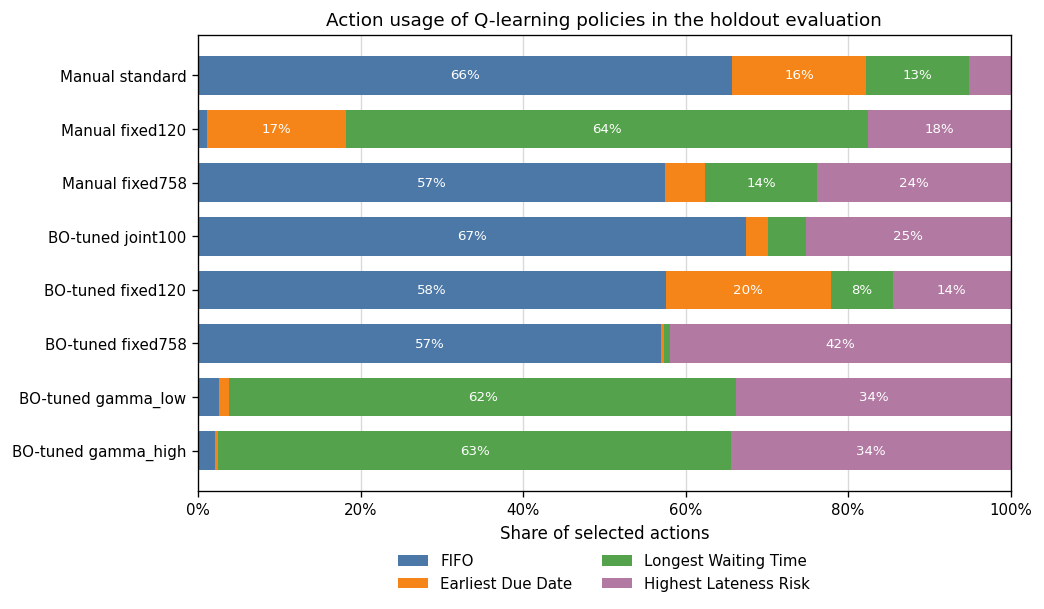

WindowsPath('C:/Workspace ZHAW/6. Semester/BA/Thesis/BA/figures/rl_discussion/rl_q_learning_action_usage_all_policies.pdf')

In [4]:
plot_columns = [action_labels[column] for column in action_columns]
colors = {
    "FIFO": "#4C78A8",
    "Earliest Due Date": "#F58518",
    "Longest Waiting Time": "#54A24B",
    "Highest Lateness Risk": "#B279A2",
}

fig_height = max(4.6, 0.48 * len(usage) + 1.4)
fig, ax = plt.subplots(figsize=(8.8, fig_height))

y = np.arange(len(usage))
left = np.zeros(len(usage))

for column in plot_columns:
    values = usage[column].to_numpy(dtype=float)
    bars = ax.barh(y, values, left=left, color=colors[column], label=column, height=0.72)
    for bar, value, start in zip(bars, values, left):
        if value >= 0.075:
            ax.text(
                start + value / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{value * 100:.0f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=8,
            )
    left += values

ax.set_yticks(y)
ax.set_yticklabels(usage["policy_label"])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Share of selected actions")
ax.set_title("Action usage of Q-learning policies in the holdout evaluation")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x * 100:.0f}%")
ax.grid(axis="x", color="#d9d9d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)

fig.tight_layout()

stem = "rl_q_learning_action_usage_all_policies"
for suffix in ["pdf", "png"]:
    fig.savefig(FIGURE_DIR / f"{stem}.{suffix}", bbox_inches="tight")

usage.to_csv(FIGURE_DIR / f"{stem}.csv", index=False)
plt.show()

FIGURE_DIR / f"{stem}.pdf"

## Stage-1 vs. Stage-2 Reward Across Tuning Variants

This figure compares the Stage-1 reward estimates with the Stage-2 reward estimates for all candidates that were passed from Stage 1 to Stage 2 across the final tuning variants. It is intended to support the discussion of selection effects and stochastic re-evaluation.

In [5]:
tuning_runs = [
    ("rl_tuning_hpc_100", "joint100"),
    ("rl_tuning_hpc_fixed120", "fixed120"),
    ("rl_tuning_hpc_fixed758", "fixed758"),
    ("rl_tuning_hpc_gamma_low", "gamma_low"),
    ("rl_tuning_hpc_gamma_high", "gamma_high"),
]

stage_rows = []
for run_dir, label in tuning_runs:
    candidates_path = RL_DIR / "results" / "rl_tuning_results" / run_dir / "stage2" / "stage2_candidates.csv"
    if not candidates_path.exists():
        print(f"Skipping missing candidates file: {candidates_path}")
        continue
    candidates = pd.read_csv(candidates_path)
    for _, row in candidates.iterrows():
        stage_rows.append({
            "run_dir": run_dir,
            "variant": label,
            "candidate_rank_stage1": int(row["candidate_rank"]),
            "source_trial_index": int(row["source_trial_index"]),
            "stage1_reward_mean": float(row["stage1_total_reward_mean"]),
            "stage2_reward_mean": float(row["total_reward_mean"]),
            "stage2_reward_std": float(row["total_reward_std"]),
            "stage2_late_order_fraction_mean": float(row["late_order_fraction_mean"]),
        })

stage_comparison = pd.DataFrame(stage_rows)
stage_comparison.head()

,run_dir,variant,candidate_rank_stage1,source_trial_index,stage1_reward_mean,stage2_reward_mean,stage2_reward_std,stage2_late_order_fraction_mean
0,rl_tuning_hpc_100,joint100,2,51,300.2,356.833333,319.176428,0.420611
1,rl_tuning_hpc_100,joint100,6,57,280.2,355.500000,314.600321,0.420922
2,rl_tuning_hpc_100,joint100,5,52,286.2,354.833333,304.673605,0.421014
3,rl_tuning_hpc_100,joint100,8,72,276.2,336.833333,305.197176,0.424170
4,rl_tuning_hpc_100,joint100,3,53,290.2,324.166667,312.356680,0.426467


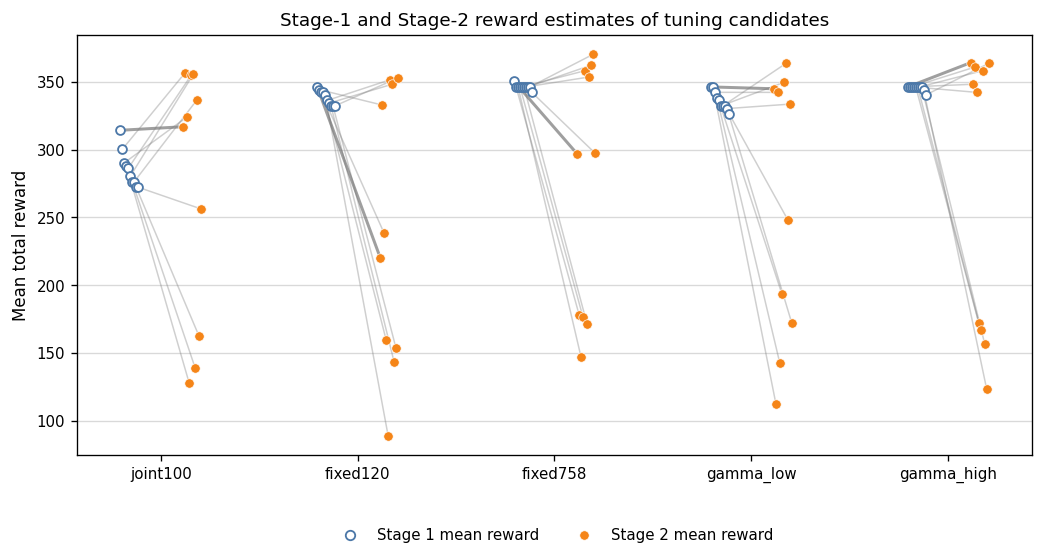

WindowsPath('C:/Workspace ZHAW/6. Semester/BA/Thesis/BA/figures/rl_discussion/rl_stage1_vs_stage2_reward_all_tuning_candidates.pdf')

In [6]:
variant_order = [label for _, label in tuning_runs if label in set(stage_comparison["variant"])]
variant_positions = {variant: idx for idx, variant in enumerate(variant_order)}

fig, ax = plt.subplots(figsize=(8.8, 4.8))

stage1_offset = -0.16
stage2_offset = 0.16

for variant in variant_order:
    subset = stage_comparison[stage_comparison["variant"].eq(variant)].copy()
    subset = subset.sort_values("candidate_rank_stage1")
    base_x = variant_positions[variant]
    jitter_values = np.linspace(-0.045, 0.045, len(subset)) if len(subset) > 1 else np.array([0.0])
    for jitter, (_, row) in zip(jitter_values, subset.iterrows()):
        x1 = base_x + stage1_offset + jitter
        x2 = base_x + stage2_offset + jitter
        y1 = row["stage1_reward_mean"]
        y2 = row["stage2_reward_mean"]
        alpha = 0.7 if row["candidate_rank_stage1"] == 1 else 0.35
        linewidth = 1.8 if row["candidate_rank_stage1"] == 1 else 0.9
        ax.plot([x1, x2], [y1, y2], color="#777777", alpha=alpha, linewidth=linewidth)
        ax.scatter(x1, y1, s=28, facecolors="white", edgecolors="#4C78A8", linewidth=1.1, zorder=3)
        ax.scatter(x2, y2, s=32, color="#F58518", edgecolors="white", linewidth=0.4, zorder=3)

ax.scatter([], [], s=32, facecolors="white", edgecolors="#4C78A8", linewidth=1.1, label="Stage 1 mean reward")
ax.scatter([], [], s=32, color="#F58518", edgecolors="white", linewidth=0.4, label="Stage 2 mean reward")

ax.set_xticks([variant_positions[variant] for variant in variant_order])
ax.set_xticklabels(variant_order)
ax.set_ylabel("Mean total reward")
ax.set_title("Stage-1 and Stage-2 reward estimates of tuning candidates")
ax.grid(axis="y", color="#d9d9d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False)

fig.tight_layout()

stem = "rl_stage1_vs_stage2_reward_all_tuning_candidates"
for suffix in ["pdf", "png"]:
    fig.savefig(FIGURE_DIR / f"{stem}.{suffix}", bbox_inches="tight")

stage_comparison.to_csv(FIGURE_DIR / f"{stem}.csv", index=False)
plt.show()

FIGURE_DIR / f"{stem}.pdf"